In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import scipy as sp
import pandas as pd
import odrpack as odr

In [25]:
df = pd.read_excel("p2optica.xlsx", sheet_name="h1input", header=None)

In [26]:
referenceAngle = 54.7

In [27]:
relativeAngle1 = df[3].to_numpy() - referenceAngle
relativeAngle2 = df[4].to_numpy() - referenceAngle
relativeAngle = (relativeAngle1 + relativeAngle2) / 2

In [28]:
difforder = df[0].to_numpy()
wavelengths = df[2].to_numpy()

fittingX = difforder * wavelengths
fittingY = np.sin(relativeAngle*np.pi/180)

errorTheta = np.zeros(len(relativeAngle)) + 0.1 / np.sqrt(12)
errorThetaAverage = errorTheta*np.sqrt(2)
errorSinTheta = np.abs(np.cos(relativeAngle*np.pi/180)*errorThetaAverage)

In [29]:
colors = ["#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900"]

In [30]:
def func(x, beta):
    return beta[0] * x + beta[1]

def otherfunc(x, A, B):
    return A * x + B

In [31]:
beta0 = [600,0]
#bounds = ([,1500],[-1,1])

sol = odr.odr_fit(func, fittingX, fittingY, beta0, weight_y = 1/(errorSinTheta**2))#, bounds=bounds)
#popt, pcov = sp.optimize.curve_fit(otherfunc, fittingX, fittingY, sigma=errorSinTheta, absolute_sigma=True)

print(f"cte red = {round(sol.beta[0] * 10**6,1)} pm {round(np.sqrt(sol.cov_beta[0,0]) * 10**6,1)} l/mm")
print(f"el otro parametro = {round(sol.beta[1],6)} pm {round(np.sqrt(sol.cov_beta[1,1]),6)} adimensional")
#print(f"cte red = {round(popt[0] * 10**6,1)} pm {round(np.sqrt(pcov[0,0]) * 10**6,1)} l/mm")
#print(sol.sd_beta[0]*10**6) #god knows what this is
#print(np.sqrt(sol.cov_beta[0,0])*10**6)                              #THIS IS MY UNCERTAINTY!!!!
#print(sol.beta)
print(sol.beta * 10**6)
print(sol.sd_beta * 10**6)
print(f"chisq red = {sol.sum_square/(len(fittingX)-len(sol.beta))}")  #THIS IS CHICUADRADO REDUCIDO!!!
print(f"pearson = {sp.stats.pearsonr(fittingX, fittingY).statistic}") #okay gg
print(f"R^2 = {sp.stats.pearsonr(fittingX, fittingY).statistic**2}") #okay gg

cte red = 606.9 pm 8.6 l/mm
el otro parametro = 0.002678 pm 0.007684 adimensional
[ 606.90123365 2678.15687682]
[  0.62892252 559.75188163]
chisq red = 0.005306531788427037
pearson = 0.9999903332614773
R^2 = 0.9999806666164005


In [32]:
'''datax = fittingX
datay = fittingY
dataDeltaY = errorSinTheta

y_pred = otherfunc(datax, *popt)
r = datay - y_pred
chisq = sum((r / dataDeltaY) ** 2)
chisqRed = chisq / (len(datax)-len(popt))

mediax = np.mean(datax)
mediay = np.mean(datay)
mediaxy = np.mean(datax*datay)
sigmax = np.std(datax)
sigmay = np.std(datay)

coefPearson = (mediaxy-mediax*mediay)/(sigmax*sigmay)

print(f"chicuadrado red = {chisqRed}")
print(f"pearson = {coefPearson}")
print(f"R^2 = {round(coefPearson**2,10)}")'''

'datax = fittingX\ndatay = fittingY\ndataDeltaY = errorSinTheta\n\ny_pred = otherfunc(datax, *popt)\nr = datay - y_pred\nchisq = sum((r / dataDeltaY) ** 2)\nchisqRed = chisq / (len(datax)-len(popt))\n\nmediax = np.mean(datax)\nmediay = np.mean(datay)\nmediaxy = np.mean(datax*datay)\nsigmax = np.std(datax)\nsigmay = np.std(datay)\n\ncoefPearson = (mediaxy-mediax*mediay)/(sigmax*sigmay)\n\nprint(f"chicuadrado red = {chisqRed}")\nprint(f"pearson = {coefPearson}")\nprint(f"R^2 = {round(coefPearson**2,10)}")'

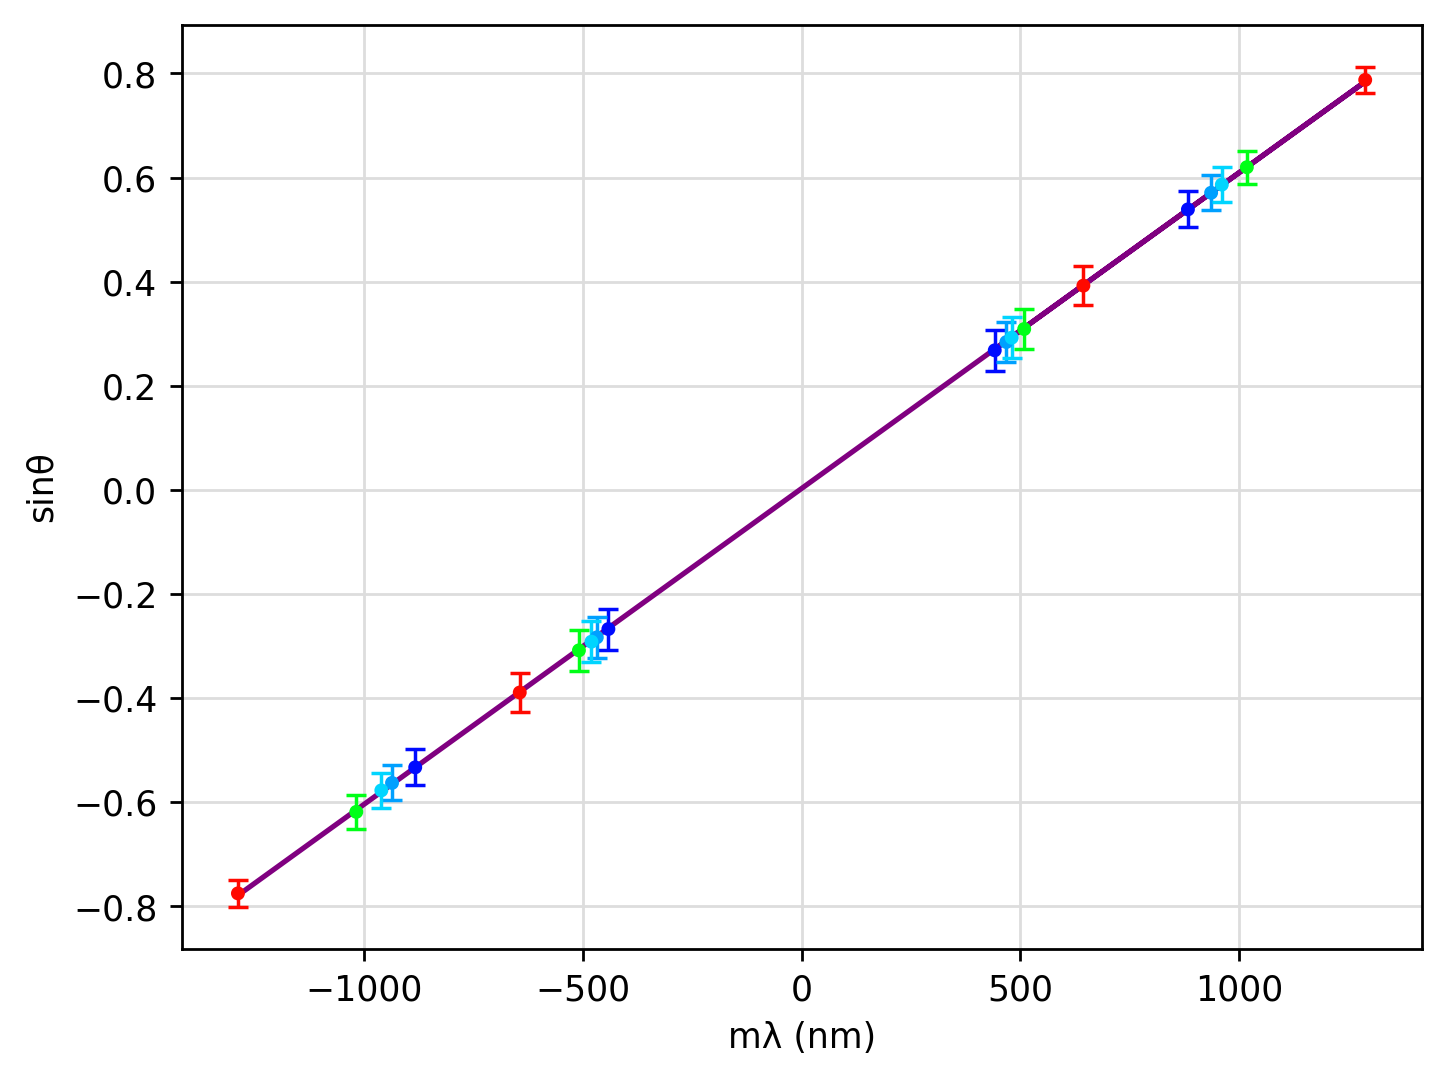

In [33]:
fig, ax = plt.subplots(dpi = 250)

ax.scatter(fittingX, fittingY, c=colors, marker=".", zorder = 12)
for i in range(len(fittingX)):
    ax.errorbar(fittingX[i], fittingY[i], yerr = errorSinTheta[i], fmt = "none",  elinewidth=1, ecolor=colors[i], capsize = 3, zorder = 10)
ax.plot(fittingX, func(fittingX, sol.beta), color="purple", zorder = 2)

ax.grid(c = "#dddddd", zorder = 0)
ax.set_xlabel("mλ (nm)")
ax.set_ylabel("sinθ")

plt.savefig("gratingFit.png", dpi = 250)
plt.show()